<a href="https://colab.research.google.com/github/7amzaGH/TUBLEX-Bubble-Plume-Analysis/blob/main/notebooks/01_TUBLEX_RF_Training_and_Selected_Model_Evaluation_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUBLEX Random Forest Training and Explainable Evaluation

**Repository:** [TUBLEX-Bubble-Plume-Analysis](https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis)

This notebook trains and evaluates a Random Forest classifier for underwater gas leak indication using the TUBLEX bubble plume descriptor dataset.

The notebook includes:

- dataset loading
- video-level train/test split
- Random Forest ablation study
- final model evaluation
- confusion matrix, ROC curve, and precision-recall curve
- feature importance
- SHAP explainability
- failure analysis for difficult samples

Only the 11 TUBLEX bubble descriptor features are used for training. Experimental metadata such as gauge, pressure, condition ID, and data group are used only for reporting and leakage checking.

In [1]:
# ============================================================
# Clone the TUBLEX GitHub repository
# ============================================================

from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis.git"
REPO_NAME = "TUBLEX-Bubble-Plume-Analysis"

# In Google Colab, clone the repository into /content.
# Locally, this cell simply uses the current working directory.
if Path("/content").exists():
    REPO_PATH = Path("/content") / REPO_NAME

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print("Repository already exists:", REPO_PATH)

    os.chdir(REPO_PATH)
else:
    REPO_PATH = Path.cwd()

PROJECT_ROOT = Path.cwd().resolve()

print("Project root:", PROJECT_ROOT)
print("Repository contents:")
print([p.name for p in PROJECT_ROOT.iterdir() if not p.name.startswith(".")])


Project root: /content/TUBLEX-Bubble-Plume-Analysis
Repository contents:
['models', 'requirements.txt', 'LICENSE', 'src', 'README.md', 'data', 'results']


In [2]:
# ============================================================
# Install required Python packages
# ============================================================

from pathlib import Path
import subprocess
import sys

PROJECT_ROOT = Path.cwd().resolve()
REQUIREMENTS_PATH = PROJECT_ROOT / "requirements.txt"

if REQUIREMENTS_PATH.exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(REQUIREMENTS_PATH)],
        check=True,
    )
    print("Installed dependencies from:", REQUIREMENTS_PATH)
else:
    fallback_packages = [
        "numpy",
        "pandas",
        "scikit-learn",
        "joblib",
        "matplotlib",
        "shap",
        "opencv-python",
        "tqdm",
    ]

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + fallback_packages,
        check=True,
    )
    print("requirements.txt not found. Installed fallback packages.")


Installed dependencies from: /content/TUBLEX-Bubble-Plume-Analysis/requirements.txt


In [3]:
# ============================================================
# Import libraries and define reproducible repository paths
# ============================================================

import json
import warnings
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tublex.config import FEATURE_COLUMNS

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# -------------------------------------------------------------------
# Input data
# -------------------------------------------------------------------
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tublex_window_features.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "metadata" / "tublex_video_metadata.csv"
SPLIT_PATH = PROJECT_ROOT / "data" / "splits" / "tublex_video_level_split_seed42.csv"

# -------------------------------------------------------------------
# Output structure used by the public repository
# -------------------------------------------------------------------
OUTPUT_DIR = PROJECT_ROOT / "results" / "selected_model_rf"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
SHAP_DIR = OUTPUT_DIR / "shap"

# Final selected RF model is stored in /models, not inside /results.
MODEL_DIR = PROJECT_ROOT / "models" / "random_forest"
MODEL_PATH = MODEL_DIR / "rf_tublex_final.joblib"
MODEL_METADATA_PATH = MODEL_DIR / "rf_tublex_metadata.json"

for folder in [TABLE_DIR, FIGURE_DIR, SHAP_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RF_PARAMS = {
    "n_estimators": 100,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Metadata:", METADATA_PATH)
print("Split:", SPLIT_PATH)
print("Tables:", TABLE_DIR)
print("Figures:", FIGURE_DIR)
print("SHAP:", SHAP_DIR)
print("Model path:", MODEL_PATH)
print("Model metadata:", MODEL_METADATA_PATH)


Project root: /content/TUBLEX-Bubble-Plume-Analysis
Dataset: /content/TUBLEX-Bubble-Plume-Analysis/data/processed/tublex_window_features.csv
Metadata: /content/TUBLEX-Bubble-Plume-Analysis/data/metadata/tublex_video_metadata.csv
Split: /content/TUBLEX-Bubble-Plume-Analysis/data/splits/tublex_video_level_split_seed42.csv
Tables: /content/TUBLEX-Bubble-Plume-Analysis/results/selected_model_rf/tables
Figures: /content/TUBLEX-Bubble-Plume-Analysis/results/selected_model_rf/figures
SHAP: /content/TUBLEX-Bubble-Plume-Analysis/results/selected_model_rf/shap
Model path: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_final.joblib
Model metadata: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_metadata.json


In [4]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(METADATA_PATH)

print("=" * 70)
print("TUBLEX DATASET SUMMARY")
print("=" * 70)

print("Dataset shape:", df.shape)
print("Metadata shape:", metadata.shape)

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nUnique source videos:", df["source_video_id"].nunique())


TUBLEX DATASET SUMMARY
Dataset shape: (2504, 15)
Metadata shape: (85, 8)

Label distribution:
label
0    1252
1    1252
Name: count, dtype: int64

Unique source videos: 85


In [ ]:
# ============================================================
# FEATURE GROUPS
# ============================================================

DENSITY_FEATURES = [
    "mean_bubble_count",
    "max_bubble_count",
]

STABILITY_FEATURES = [
    "std_bubble_count",
    "temporal_variance",
    "leak_evolution",
]

GEOMETRY_FEATURES = [
    "continuity_ratio",
    "mean_vertical_chain",
]

TEMPORAL_HISTORY_FEATURES = [
    "prev3_mean_bubble_count",
    "prev3_std_bubble_count",
    "prev3_continuity_ratio",
    "prev3_mean_vertical_chain",
]

# Use the same canonical feature order defined in src/tublex/config.py.
# This is important because the saved model metadata must match training order exactly.
ALL_FEATURES = list(FEATURE_COLUMNS)

TARGET = "label"

FORBIDDEN_FEATURES = [
    "sample_id",
    "source_video_id",
    "window_id",
    "time_sec",
    "condition_id",
    "data_group",
    "g",
    "psi",
]

for col in ALL_FEATURES:
    assert col in df.columns, f"Missing feature: {col}"

assert len(set(ALL_FEATURES).intersection(FORBIDDEN_FEATURES)) == 0

print("TUBLEX model features:")
for i, feature in enumerate(ALL_FEATURES, start=1):
    print(f"{i:02d}. {feature}")

print("\nNo metadata columns are used as model features.")


TUBLEX model features:
01. mean_bubble_count
02. max_bubble_count
03. std_bubble_count
04. temporal_variance
05. leak_evolution
06. continuity_ratio
07. mean_vertical_chain
08. prev3_mean_bubble_count
09. prev3_std_bubble_count
10. prev3_continuity_ratio
11. prev3_mean_vertical_chain

No metadata columns are used as model features.


In [ ]:
# ============================================================
# VIDEO-LEVEL TRAIN/TEST SPLIT
# ============================================================

if SPLIT_PATH.exists():
    split_df = pd.read_csv(SPLIT_PATH)
    print("Loaded existing split:", SPLIT_PATH)

else:
    print("Creating new video-level split with seed 42.")

    splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=0.8,
        random_state=RANDOM_STATE,
    )

    X_temp = df[ALL_FEATURES]
    y_temp = df[TARGET]
    groups_temp = df["source_video_id"]

    train_idx_temp, test_idx_temp = next(splitter.split(X_temp, y_temp, groups_temp))

    train_videos_temp = set(df.iloc[train_idx_temp]["source_video_id"])
    test_videos_temp = set(df.iloc[test_idx_temp]["source_video_id"])

    split_df = pd.DataFrame({
        "source_video_id": sorted(df["source_video_id"].unique())
    })

    split_df["split"] = split_df["source_video_id"].apply(
        lambda x: "train" if x in train_videos_temp else "test"
    )

    SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
    split_df.to_csv(SPLIT_PATH, index=False)

    print("Saved split:", SPLIT_PATH)

train_videos = set(split_df.loc[split_df["split"] == "train", "source_video_id"])
test_videos = set(split_df.loc[split_df["split"] == "test", "source_video_id"])

assert train_videos.isdisjoint(test_videos)
assert train_videos.union(test_videos) == set(df["source_video_id"].unique())

train_mask = df["source_video_id"].isin(train_videos)
test_mask = df["source_video_id"].isin(test_videos)

X_train = df.loc[train_mask, ALL_FEATURES]
X_test = df.loc[test_mask, ALL_FEATURES]

y_train = df.loc[train_mask, TARGET]
y_test = df.loc[test_mask, TARGET]

groups_train = df.loc[train_mask, "source_video_id"]

split_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Windows": [len(X_train), len(X_test)],
    "Videos": [len(train_videos), len(test_videos)],
    "Leak": [int((y_train == 1).sum()), int((y_test == 1).sum())],
    "Non-Leak": [int((y_train == 0).sum()), int((y_test == 0).sum())],
})

split_summary.to_csv(TABLE_DIR / "video_level_split_summary.csv", index=False)

display(split_summary)


Loaded existing split: data/splits/tublex_video_level_split_seed42.csv


,Split,Windows,Videos,Leak,Non-Leak
0,Train,2009,68,999,1010
1,Test,495,17,253,242


In [ ]:
# ============================================================
# ABLATION EXPERIMENTS
# ============================================================

experiments = {
    "E1: Naive Mean Count": ["mean_bubble_count"],
    "E2: Density Only": DENSITY_FEATURES,
    "E3: E2 + Stability": DENSITY_FEATURES + STABILITY_FEATURES,
    "E4: E3 + Geometry": DENSITY_FEATURES + STABILITY_FEATURES + GEOMETRY_FEATURES,
    "E5: Full TUBLEX": ALL_FEATURES,
}

experiment_table = pd.DataFrame({
    "Experiment": list(experiments.keys()),
    "N Features": [len(v) for v in experiments.values()],
    "Features": [", ".join(v) for v in experiments.values()],
})

experiment_table.to_csv(TABLE_DIR / "ablation_experiment_definitions.csv", index=False)

display(experiment_table)


,Experiment,N Features,Features
0,E1: Naive Mean Count,1,mean_bubble_count
1,E2: Density Only,2,"mean_bubble_count, max_bubble_count"
2,E3: E2 + Stability,5,"mean_bubble_count, max_bubble_count, std_bubbl..."
3,E4: E3 + Geometry,7,"mean_bubble_count, max_bubble_count, std_bubbl..."
4,E5: Full TUBLEX,11,"mean_bubble_count, max_bubble_count, std_bubbl..."


In [ ]:
# ============================================================
# RANDOM FOREST ABLATION STUDY
# ============================================================

gkf = GroupKFold(n_splits=5)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

ablation_results = []

print("=" * 70)
print("RUNNING RANDOM FOREST ABLATION STUDY")
print("=" * 70)

for exp_name, feature_cols in experiments.items():

    model = RandomForestClassifier(**RF_PARAMS)

    cv_results = cross_validate(
        model,
        X_train[feature_cols],
        y_train,
        groups=groups_train,
        cv=gkf,
        scoring=scoring,
        n_jobs=-1,
    )

    model.fit(X_train[feature_cols], y_train)

    pred = model.predict(X_test[feature_cols])
    prob = model.predict_proba(X_test[feature_cols])[:, 1]

    row = {
        "Experiment": exp_name,
        "N Features": len(feature_cols),
        "CV Accuracy": cv_results["test_accuracy"].mean(),
        "CV F1": cv_results["test_f1"].mean(),
        "CV F1 Std": cv_results["test_f1"].std(),
        "CV ROC-AUC": cv_results["test_roc_auc"].mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred),
        "Test Recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, prob),
        "Test PR-AUC": average_precision_score(y_test, prob),
    }

    ablation_results.append(row)

    print(f"\n{exp_name}")
    print(f"Features: {len(feature_cols)}")
    print(f"CV F1:   {row['CV F1']:.4f} ± {row['CV F1 Std']:.4f}")
    print(f"Test F1: {row['Test F1']:.4f}")
    print(f"ROC-AUC: {row['Test ROC-AUC']:.4f}")

ablation_df = pd.DataFrame(ablation_results)

ablation_display = ablation_df.copy()
metric_cols = [c for c in ablation_display.columns if c not in ["Experiment", "N Features"]]
ablation_display[metric_cols] = ablation_display[metric_cols].round(4)

ablation_path = TABLE_DIR / "rf_ablation_results.csv"
ablation_display.to_csv(ablation_path, index=False)

display(ablation_display)

print("Saved:", ablation_path)


RUNNING RANDOM FOREST ABLATION STUDY

E1: Naive Mean Count
Features: 1
CV F1:   0.8164 ± 0.0913
Test F1: 0.7860
ROC-AUC: 0.7633

E2: Density Only
Features: 2
CV F1:   0.8682 ± 0.1031
Test F1: 0.8522
ROC-AUC: 0.7884

E3: E2 + Stability
Features: 5
CV F1:   0.9784 ± 0.0177
Test F1: 0.9941
ROC-AUC: 0.9999

E4: E3 + Geometry
Features: 7
CV F1:   0.9900 ± 0.0044
Test F1: 0.9921
ROC-AUC: 0.9998

E5: Full TUBLEX
Features: 11
CV F1:   0.9904 ± 0.0046
Test F1: 0.9941
ROC-AUC: 0.9999


,Experiment,N Features,CV Accuracy,CV F1,CV F1 Std,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,E1: Naive Mean Count,1,0.8127,0.8164,0.0913,0.8530,0.7657,0.7370,0.8419,0.7860,0.7633,0.6618
1,E2: Density Only,2,0.8625,0.8682,0.1031,0.8815,0.8283,0.7609,0.9684,0.8522,0.7884,0.6968
2,E3: E2 + Stability,5,0.9781,0.9784,0.0177,0.9976,0.9939,0.9960,0.9921,0.9941,0.9999,0.9999
3,E4: E3 + Geometry,7,0.9896,0.9900,0.0044,0.9985,0.9919,0.9960,0.9881,0.9921,0.9998,0.9998
4,E5: Full TUBLEX,11,0.9901,0.9904,0.0046,0.9986,0.9939,0.9960,0.9921,0.9941,0.9999,0.9999


Saved: results/rf_evaluation/rf_ablation_results.csv


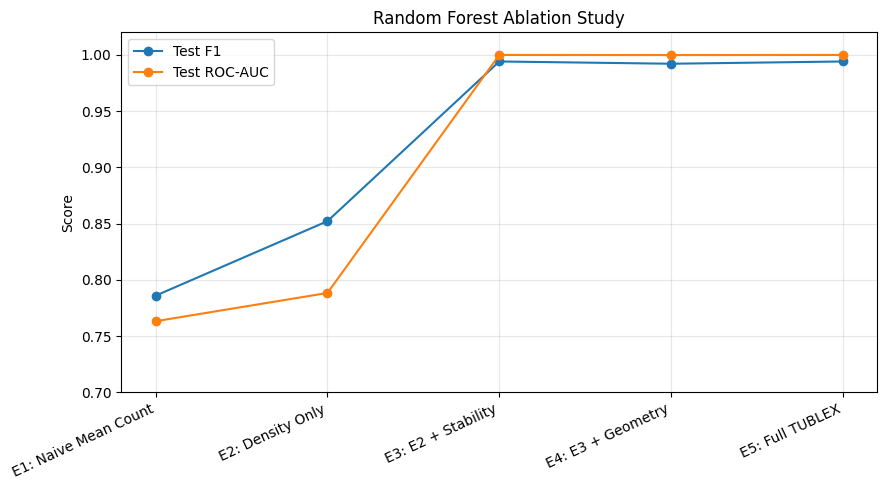

Saved: results/rf_evaluation/figures/rf_ablation_results.png


In [ ]:
# ============================================================
# PLOT ABLATION RESULTS
# ============================================================

plot_df = ablation_display.copy()

plt.figure(figsize=(9, 5))

plt.plot(plot_df["Experiment"], plot_df["Test F1"], marker="o", label="Test F1")
plt.plot(plot_df["Experiment"], plot_df["Test ROC-AUC"], marker="o", label="Test ROC-AUC")

plt.xticks(rotation=25, ha="right")
plt.ylim(0.70, 1.02)
plt.ylabel("Score")
plt.title("Random Forest Ablation Study")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "rf_ablation_results.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# ============================================================
# FINAL RANDOM FOREST TRAINING
# ============================================================

final_rf = RandomForestClassifier(**RF_PARAMS)

final_rf.fit(X_train[ALL_FEATURES], y_train)

y_pred = final_rf.predict(X_test[ALL_FEATURES])
y_prob = final_rf.predict_proba(X_test[ALL_FEATURES])[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
}

final_metrics_df = pd.DataFrame({
    "Metric": list(final_metrics.keys()),
    "Value": list(final_metrics.values()),
})

final_metrics_df["Value"] = final_metrics_df["Value"].round(4)

final_metrics_df.to_csv(TABLE_DIR / "rf_final_metrics.csv", index=False)

display(final_metrics_df)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Non-Leak", "Leak"]))


,Metric,Value
0,Accuracy,0.9939
1,Precision,0.9960
2,Recall,0.9921
3,F1,0.9941
4,ROC-AUC,0.9999
5,PR-AUC,0.9999



Classification report:
              precision    recall  f1-score   support

    Non-Leak       0.99      1.00      0.99       242
        Leak       1.00      0.99      0.99       253

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



In [ ]:
# ============================================================
# SAVE SELECTED RF MODEL, METADATA, AND TEST PREDICTIONS
# ============================================================

prediction_path = TABLE_DIR / "rf_test_predictions.csv"

joblib.dump(final_rf, MODEL_PATH)

model_metadata = {
    "model_name": "TUBLEX Random Forest",
    "model_type": "RandomForestClassifier",
    "positive_class": 1,
    "decision_threshold": 0.5,
    "feature_columns": ALL_FEATURES,
}

with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2)

prediction_base_cols = [
    c for c in [
        "sample_id",
        "source_video_id",
        "window_id",
        "time_sec",
        "label",
    ]
    if c in df.columns
]

predictions_df = df.loc[test_mask, prediction_base_cols].copy()
predictions_df["predicted_label"] = y_pred
predictions_df["leak_probability"] = y_prob

predictions_df = predictions_df.merge(metadata, on="source_video_id", how="left")

predictions_df.to_csv(prediction_path, index=False)

print("Saved selected RF model:", MODEL_PATH)
print("Saved model metadata:", MODEL_METADATA_PATH)
print("Saved predictions:", prediction_path)

display(predictions_df.head())


Saved model: results/rf_evaluation/models/rf_tublex_final_model.joblib
Saved feature list: results/rf_evaluation/models/rf_feature_columns.json
Saved predictions: results/rf_evaluation/rf_test_predictions.csv


,sample_id,source_video_id,window_id,label,predicted_label,leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1
0,L_G12_PSI05_V001_W0000,L_G12_PSI05_V001,0,0,0,0.00,G12_PSI05,leak,12,5,40,8,32
1,L_G12_PSI05_V001_W0001,L_G12_PSI05_V001,1,0,0,0.00,G12_PSI05,leak,12,5,40,8,32
2,L_G12_PSI05_V001_W0002,L_G12_PSI05_V001,2,0,0,0.00,G12_PSI05,leak,12,5,40,8,32
3,L_G12_PSI05_V001_W0003,L_G12_PSI05_V001,3,0,0,0.01,G12_PSI05,leak,12,5,40,8,32
4,L_G12_PSI05_V001_W0004,L_G12_PSI05_V001,4,0,0,0.00,G12_PSI05,leak,12,5,40,8,32


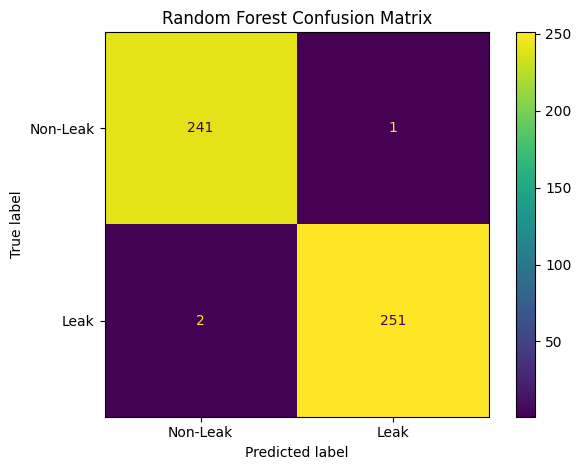

Saved: results/rf_evaluation/figures/rf_confusion_matrix.png
[[241   1]
 [  2 251]]


In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Leak", "Leak"],
)

disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

fig_path = FIGURE_DIR / "rf_confusion_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print(cm)


In [ ]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance": final_rf.feature_importances_,
}).sort_values("Importance", ascending=False)

importance_df["Importance"] = importance_df["Importance"].round(6)

importance_path = TABLE_DIR / "rf_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

display(importance_df)

print("Saved:", importance_path)


,Feature,Importance
2,std_bubble_count,0.273597
3,temporal_variance,0.267091
6,mean_vertical_chain,0.163883
8,prev3_std_bubble_count,0.098817
10,prev3_mean_vertical_chain,0.081673
9,prev3_continuity_ratio,0.029614
5,continuity_ratio,0.023094
1,max_bubble_count,0.021936
0,mean_bubble_count,0.019077
4,leak_evolution,0.015151


Saved: results/rf_evaluation/rf_feature_importance.csv


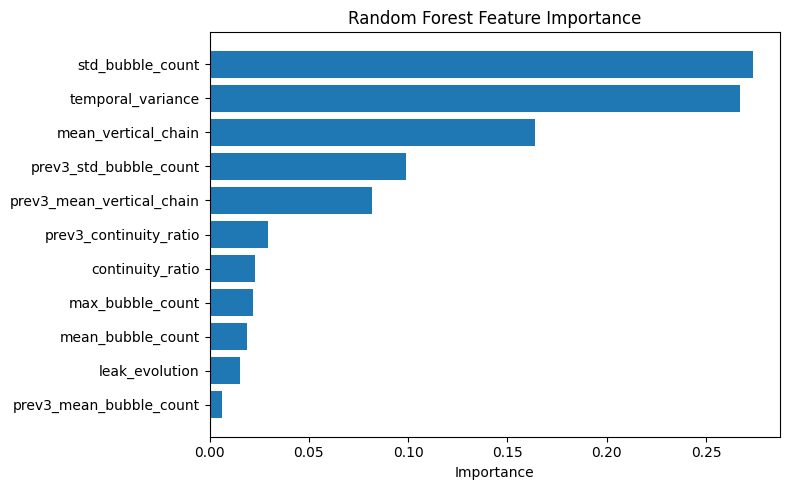

Saved: results/rf_evaluation/figures/rf_feature_importance.png


In [ ]:
# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

plot_df = importance_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Feature"], plot_df["Importance"])

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

fig_path = FIGURE_DIR / "rf_feature_importance.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# ============================================================
# SHAP SETUP
# ============================================================

try:
    import shap
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

from IPython.display import display, HTML

shap.initjs()

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [ ]:
# ============================================================
# COMPUTE SHAP VALUES
# ============================================================

X_test_shap = X_test[ALL_FEATURES].reset_index(drop=True)

test_info = predictions_df.reset_index(drop=True).copy()

explainer = shap.TreeExplainer(final_rf)
shap_values_raw = explainer.shap_values(X_test_shap)

# Robust binary-class handling
if isinstance(shap_values_raw, list):
    shap_non_leak = shap_values_raw[0]
    shap_leak = shap_values_raw[1]
else:
    shap_values_raw = np.asarray(shap_values_raw)

    if shap_values_raw.ndim == 3:
        shap_non_leak = shap_values_raw[:, :, 0]
        shap_leak = shap_values_raw[:, :, 1]
    else:
        shap_leak = shap_values_raw
        shap_non_leak = -shap_values_raw

expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    base_non_leak = float(expected_value[0])
    base_leak = float(expected_value[1])
else:
    base_leak = float(expected_value)
    base_non_leak = 1.0 - base_leak

print("X_test_shap:", X_test_shap.shape)
print("SHAP Leak:", np.asarray(shap_leak).shape)
print("SHAP Non-Leak:", np.asarray(shap_non_leak).shape)

assert np.asarray(shap_leak).shape == X_test_shap.shape
assert np.asarray(shap_non_leak).shape == X_test_shap.shape


X_test_shap: (495, 11)
SHAP Leak: (495, 11)
SHAP Non-Leak: (495, 11)


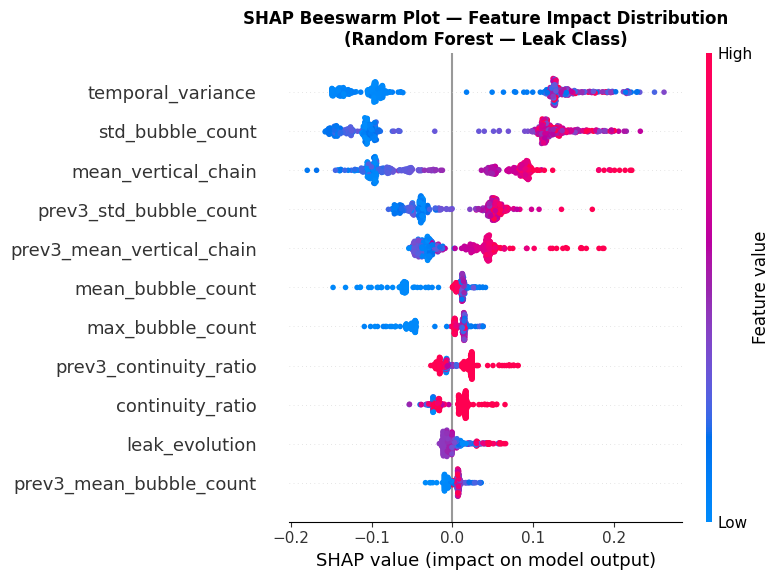

Saved: results/rf_evaluation/shap/shap_beeswarm_leak_class.png


In [ ]:
# ============================================================
# SHAP BEESWARM PLOT — LEAK CLASS IMPACT DISTRIBUTION
# ============================================================

# Leak-class SHAP values
sv = shap_leak

plt.figure(figsize=(8, 5))

shap.summary_plot(
    sv,
    X_test_shap,
    feature_names=ALL_FEATURES,
    show=False,
)

plt.title(
    "SHAP Beeswarm Plot — Feature Impact Distribution\n"
    "(Random Forest — Leak Class)",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()

fig_path = SHAP_DIR / "shap_beeswarm_leak_class.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# ============================================================
# SHAP SUMMARY BAR TABLE — LEAK VS NON-LEAK
# ============================================================

actual_non_leak = test_info["label"].values == 0
actual_leak = test_info["label"].values == 1

shap_bar_df = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Mean |SHAP| Non-Leak": np.abs(shap_non_leak[actual_non_leak]).mean(axis=0),
    "Mean |SHAP| Leak": np.abs(shap_leak[actual_leak]).mean(axis=0),
})

shap_bar_df["Mean |SHAP| Overall"] = (
    shap_bar_df["Mean |SHAP| Non-Leak"] + shap_bar_df["Mean |SHAP| Leak"]
) / 2

shap_bar_df = shap_bar_df.sort_values("Mean |SHAP| Overall", ascending=False)

shap_bar_path = SHAP_DIR / "shap_summary_bar_leak_vs_non_leak.csv"
shap_bar_df.round(6).to_csv(shap_bar_path, index=False)

display(shap_bar_df.round(6))

print("Saved:", shap_bar_path)


,Feature,Mean |SHAP| Non-Leak,Mean |SHAP| Leak,Mean |SHAP| Overall
3,temporal_variance,0.113580,0.138149,0.125865
2,std_bubble_count,0.118562,0.126180,0.122371
6,mean_vertical_chain,0.092174,0.080483,0.086329
8,prev3_std_bubble_count,0.046657,0.052334,0.049496
10,prev3_mean_vertical_chain,0.036402,0.042720,0.039561
0,mean_bubble_count,0.038764,0.014728,0.026746
1,max_bubble_count,0.032018,0.015500,0.023759
9,prev3_continuity_ratio,0.012711,0.023526,0.018119
5,continuity_ratio,0.018007,0.018012,0.018009
4,leak_evolution,0.008627,0.014201,0.011414


Saved: results/rf_evaluation/shap/shap_summary_bar_leak_vs_non_leak.csv


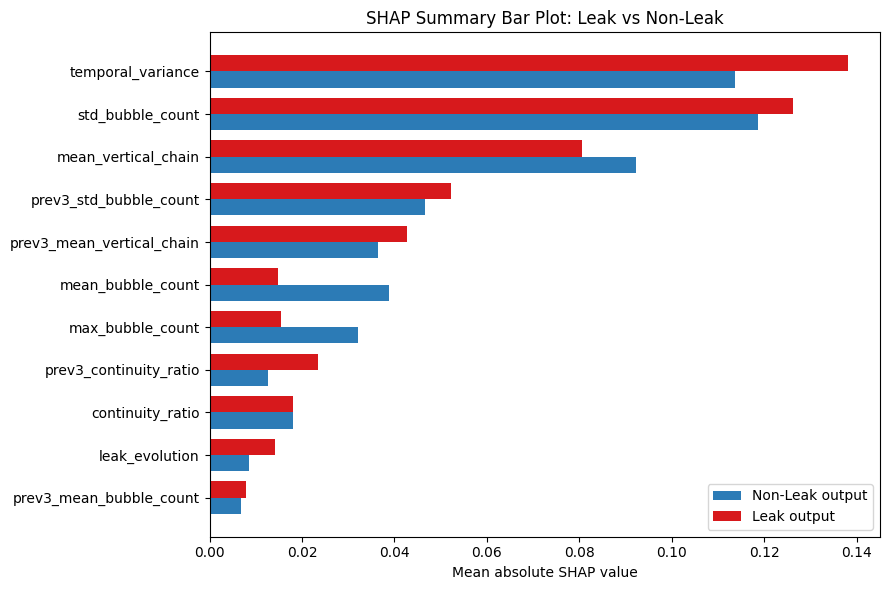

Saved: results/rf_evaluation/shap/shap_summary_bar_leak_vs_non_leak.png


In [ ]:
# ============================================================
# SHAP SUMMARY BAR PLOT — LEAK VS NON-LEAK
# ============================================================

plot_df = shap_bar_df.sort_values("Mean |SHAP| Overall", ascending=True)

y_pos = np.arange(len(plot_df))
bar_height = 0.38

plt.figure(figsize=(9, 6))

plt.barh(
    y_pos - bar_height / 2,
    plot_df["Mean |SHAP| Non-Leak"],
    height=bar_height,
    label="Non-Leak output",
    color="#2C7BB6",
)

plt.barh(
    y_pos + bar_height / 2,
    plot_df["Mean |SHAP| Leak"],
    height=bar_height,
    label="Leak output",
    color="#D7191C",
)

plt.yticks(y_pos, plot_df["Feature"])
plt.xlabel("Mean absolute SHAP value")
plt.title("SHAP Summary Bar Plot: Leak vs Non-Leak")
plt.legend()
plt.tight_layout()

fig_path = SHAP_DIR / "shap_summary_bar_leak_vs_non_leak.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


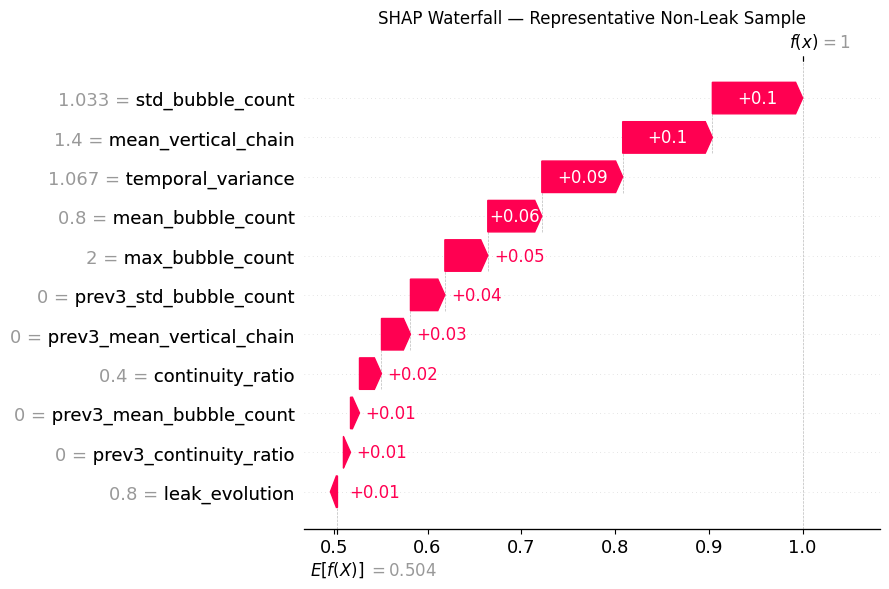

Saved: results/rf_evaluation/shap/shap_waterfall_representative_non_leak.png


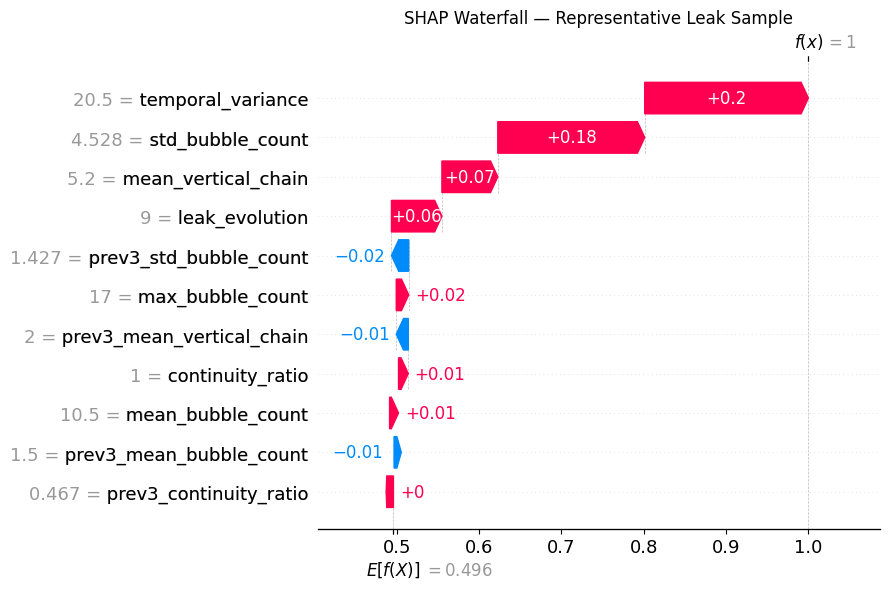

Saved: results/rf_evaluation/shap/shap_waterfall_representative_leak.png


In [ ]:
# ============================================================
# SHAP WATERFALL PLOTS
# ============================================================

def make_explanation(sample_index, class_name):
    if class_name == "leak":
        values = shap_leak[sample_index]
        base_value = base_leak
    elif class_name == "non_leak":
        values = shap_non_leak[sample_index]
        base_value = base_non_leak
    else:
        raise ValueError("class_name must be 'leak' or 'non_leak'")

    return shap.Explanation(
        values=values,
        base_values=base_value,
        data=X_test_shap.iloc[sample_index].values,
        feature_names=ALL_FEATURES,
    )

def save_waterfall(sample_index, class_name, title, filename):
    explanation = make_explanation(sample_index, class_name)

    shap.plots.waterfall(explanation, max_display=11, show=False)

    fig = plt.gcf()
    fig.set_size_inches(9, 6)
    plt.title(title)
    plt.tight_layout()

    path = SHAP_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

save_waterfall(
    sample_index=non_leak_example_idx,
    class_name="non_leak",
    title="SHAP Waterfall — Representative Non-Leak Sample",
    filename="shap_waterfall_representative_non_leak.png",
)

save_waterfall(
    sample_index=leak_example_idx,
    class_name="leak",
    title="SHAP Waterfall — Representative Leak Sample",
    filename="shap_waterfall_representative_leak.png",
)


<Figure size 1200x300 with 0 Axes>

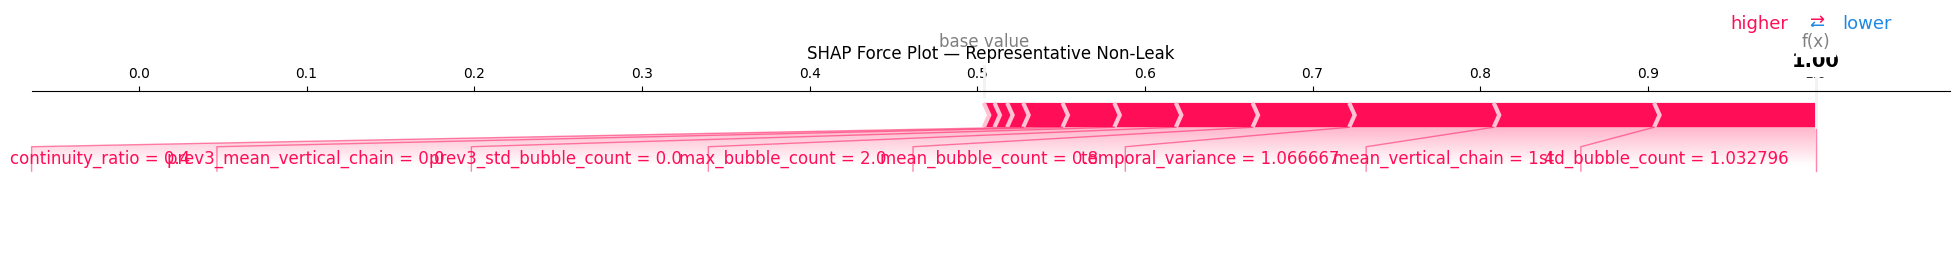

Saved static PNG: results/rf_evaluation/shap/shap_force_representative_non_leak.png
Saved interactive HTML: results/rf_evaluation/shap/shap_force_representative_non_leak.html


<Figure size 1200x300 with 0 Axes>

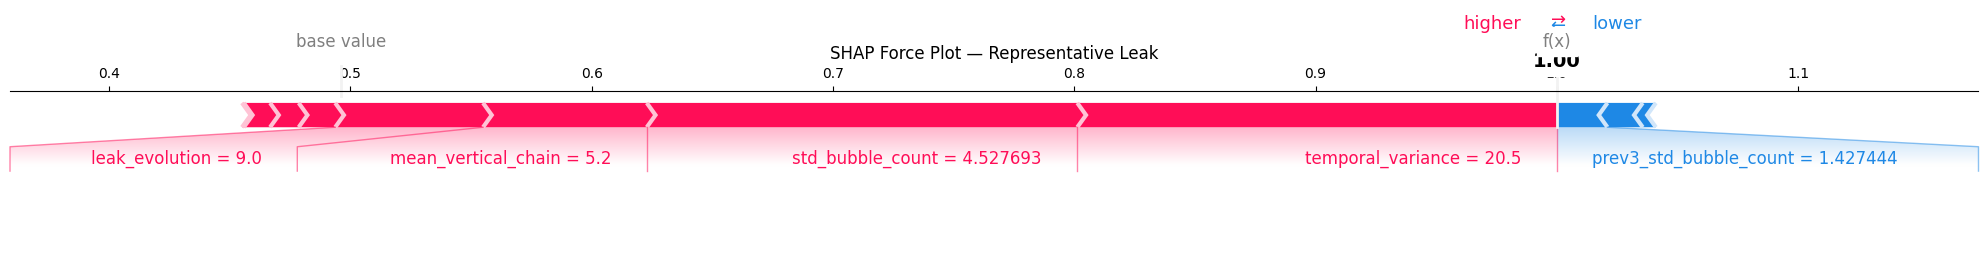

Saved static PNG: results/rf_evaluation/shap/shap_force_representative_leak.png
Saved interactive HTML: results/rf_evaluation/shap/shap_force_representative_leak.html


In [ ]:
# ============================================================
# SHAP FORCE PLOTS — STATIC PNG + INTERACTIVE HTML
# ============================================================

def save_force_plot(sample_index, class_name, title, filename_prefix):
    """
    Saves:
    1. Static PNG force plot for GitHub / paper / README
    2. Interactive HTML force plot for local notebook viewing
    """

    if class_name == "leak":
        values = shap_leak[sample_index]
        base_value = base_leak
    elif class_name == "non_leak":
        values = shap_non_leak[sample_index]
        base_value = base_non_leak
    else:
        raise ValueError("class_name must be 'leak' or 'non_leak'")

    sample_features = X_test_shap.iloc[sample_index]

    # 1. Save interactive HTML version
    force_html = shap.force_plot(
        base_value,
        values,
        sample_features,
        feature_names=ALL_FEATURES,
    )

    html_path = SHAP_DIR / f"{filename_prefix}.html"
    shap.save_html(str(html_path), force_html)

    # 2. Save static PNG version
    plt.figure(figsize=(12, 3))

    shap.force_plot(
        base_value,
        values,
        sample_features,
        feature_names=ALL_FEATURES,
        matplotlib=True,
        show=False,
    )

    plt.title(title)
    plt.tight_layout()

    png_path = SHAP_DIR / f"{filename_prefix}.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved static PNG:", png_path)
    print("Saved interactive HTML:", html_path)


save_force_plot(
    sample_index=non_leak_example_idx,
    class_name="non_leak",
    title="SHAP Force Plot — Representative Non-Leak",
    filename_prefix="shap_force_representative_non_leak",
)

save_force_plot(
    sample_index=leak_example_idx,
    class_name="leak",
    title="SHAP Force Plot — Representative Leak",
    filename_prefix="shap_force_representative_leak",
)


In [ ]:
# ============================================================
# FAILURE ANALYSIS TABLE
# ============================================================

failure_cases = test_info[test_info["prediction_type"].isin(["FP", "FN"])].copy()

failure_cases = failure_cases.sort_values("leak_probability", ascending=False)

failure_path = SHAP_DIR / "failure_cases.csv"
failure_cases.to_csv(failure_path, index=False)

print("Prediction type counts:")
display(test_info["prediction_type"].value_counts().reset_index().rename(
    columns={"index": "Prediction Type", "prediction_type": "Count"}
))

print("\nFailure cases:")
display(failure_cases)

print("Saved:", failure_path)


Prediction type counts:


,Count,count
0,TP,251
1,TN,241
2,FN,2
3,FP,1



Failure cases:


,sample_id,source_video_id,window_id,label,predicted_label,leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1,prediction_type
251,L_G24_PSI10_V001_W0047,L_G24_PSI10_V001,47,0,1,0.84,G24_PSI10,leak,24,10,46,4,42,FP
250,L_G24_PSI10_V001_W0046,L_G24_PSI10_V001,46,1,0,0.39,G24_PSI10,leak,24,10,46,4,42,FN
5,L_G12_PSI05_V001_W0005,L_G12_PSI05_V001,5,1,0,0.37,G12_PSI05,leak,12,5,40,8,32,FN


Saved: results/rf_evaluation/shap/failure_cases.csv


In [ ]:
# ============================================================
# MANUAL SAMPLE INVESTIGATION
# ============================================================

def investigate_sample(sample_id, explain_as="leak"):
    matches = test_info[test_info["sample_id"] == sample_id]

    if len(matches) == 0:
        print("Sample not found in test set.")
        return

    sample_index = int(matches.index[0])

    print("Sample information:")
    display(test_info.loc[[sample_index]])

    if explain_as == "leak":
        save_waterfall(
            sample_index=sample_index,
            class_name="leak",
            title=f"SHAP Waterfall — {sample_id} — Leak Output",
            filename=f"shap_waterfall_manual_{sample_id}_leak.png",
        )

    elif explain_as == "non_leak":
        save_waterfall(
            sample_index=sample_index,
            class_name="non_leak",
            title=f"SHAP Waterfall — {sample_id} — Non-Leak Output",
            filename=f"shap_waterfall_manual_{sample_id}_non_leak.png",
        )

    else:
        raise ValueError("explain_as must be 'leak' or 'non_leak'")


Sample information:


,sample_id,source_video_id,window_id,label,predicted_label,leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1,prediction_type
251,L_G24_PSI10_V001_W0047,L_G24_PSI10_V001,47,0,1,0.84,G24_PSI10,leak,24,10,46,4,42,FP


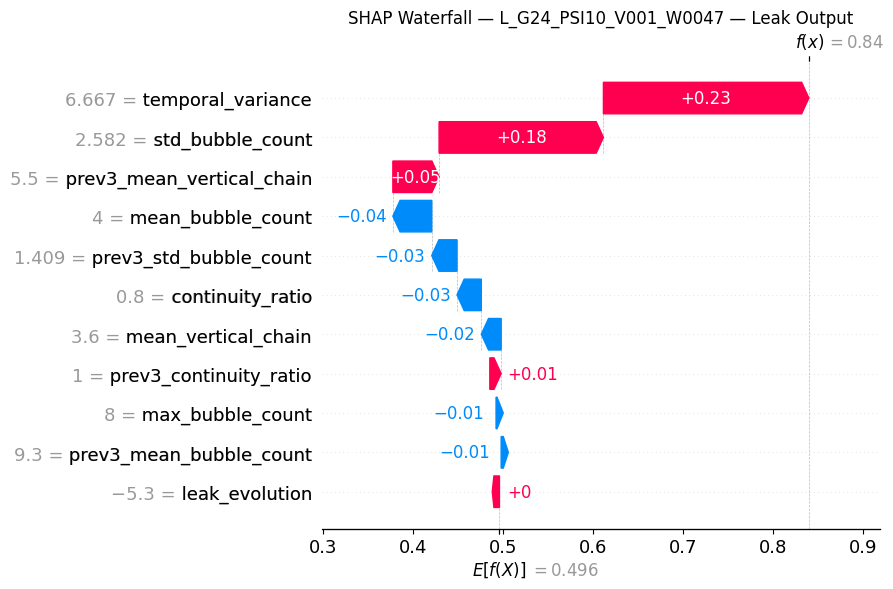

Saved: results/rf_evaluation/shap/shap_waterfall_manual_L_G24_PSI10_V001_W0047_leak.png


In [ ]:
investigate_sample("L_G24_PSI10_V001_W0047", explain_as="leak")


## Conclusion

This notebook trained and evaluated a Random Forest classifier on the TUBLEX bubble plume descriptor dataset.

The ablation study shows that density-only features provide a useful baseline, while temporal stability features produce the largest performance gain. The final model uses all 11 TUBLEX descriptors and is evaluated using a video-level split to reduce window-level leakage.

SHAP analysis provides global and sample-level interpretation of the model, including class-specific feature importance, representative Leak and Non-Leak explanations, and failure-case analysis.

Experimental metadata is intentionally excluded from model training and retained only for traceability, reporting, and leakage checking.